In [ ]:
# !wget https://dcc.ligo.org/public/0150/P1800061/011/GW170817_PSDs.dat

--2025-12-06 13:59:27--  https://dcc.ligo.org/public/0150/P1800061/011/GW170817_PSDs.dat
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14515336 (14M)
Saving to: ‘GW170817_PSDs.dat’

GW170817_PSDs.dat   100%[===================>]  13.84M  5.06MB/s    in 2.7s    

2025-12-06 13:59:31 (5.06 MB/s) - ‘GW170817_PSDs.dat’ saved [14515336/14515336]



In [5]:
# get the data for the power spectral densities (PSDs) of the LIGO and Virgo detectors
# Freq (Hz)	LIGO_Hanford_PSD (1/Hz)	LIGO_Livingston_PSD (1/Hz)	Virgo_PSD (1/Hz)
import numpy as np
data = np.loadtxt('GW170817_PSDs.dat', skiprows=1)
frequencies = data[:, 0]
ligo_hanford_psd = data[:, 1]
ligo_livingston_psd = data[:, 2]
virgo_psd = data[:, 3]

# save the PSDs in a format that bilby can read, seperatedly for each detector
np.savetxt('LIGO_Hanford_PSD.txt', np.column_stack((frequencies, ligo_hanford_psd)))
np.savetxt('LIGO_Livingston_PSD.txt', np.column_stack((frequencies, ligo_livingston_psd)))
np.savetxt('Virgo_PSD.txt', np.column_stack((frequencies, virgo_psd)))

In [ ]:
# get frequency and PSD from 'LIGO_Hanford_PSD.txt'
freqs, psd_hanford = np.loadtxt('LIGO_Hanford_PSD.txt', unpack=True)

array([  23.     ,   23.00781,   23.01562, ..., 2047.984  , 2047.992  ,
       2048.     ])

In [7]:
import numpy as np
import matplotlib.pyplot as plt

import bilby

from gwpy.timeseries import TimeSeries

/Users/phurailatpamhemantakumar/anaconda3/envs/ler/lib/python3.10/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [8]:
time_of_event = 1187008882.43
H1 = bilby.gw.detector.get_empty_interferometer("H1")
post_trigger_duration = 1
duration = 309.0
analysis_start = time_of_event + post_trigger_duration - duration

# psd_duration = duration * 32
psd_start_time = analysis_start - 1024.0

H1_psd_data = TimeSeries.read(source='/Users/phurailatpamhemantakumar/phd/mypackages/TaylorF2Ecck/Event Analysis/GW170817/configuration_files/H-H1_LOSC_CLN_4_V1-1187007040-2048.gwf', channel='H1:LOSC-STRAIN', format='gwf.lalframe', ).astype(dtype='float64', subok=True, copy=False, )

In [9]:
window='Tukey'
roll_off=0.4
alpha=2 * roll_off / duration
overlap=154.5
method='median'
psd_fractional_overlap=0.5

H1_psd = H1_psd_data.psd(fftlength=duration, overlap=psd_fractional_overlap, window=("tukey", alpha), method=method)

In [10]:
H1 = bilby.gw.detector.get_empty_interferometer("H1")
H1.sampling_frequency = 2048.0
H1.duration = duration
H1.minimum_frequency = 20.0
H1.maximum_frequency = 512.0
H1.power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)

In [11]:
H1.power_spectral_density.frequency_array.shape, H1.power_spectral_density.asd_array.shape, H1.strain_data.frequency_mask.shape

((632833,), (632833,), (316417,))

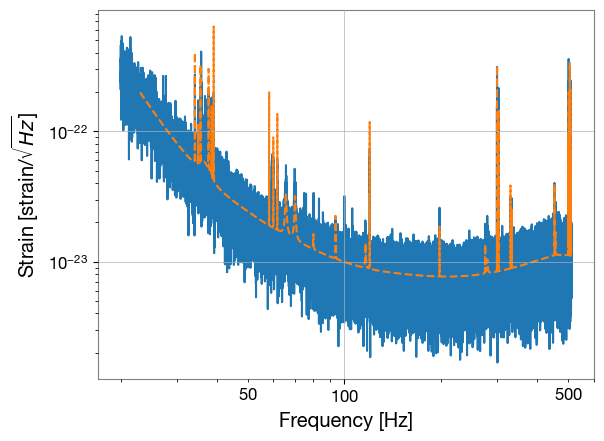

In [12]:
fig, ax = plt.subplots()
# idxs = H1.strain_data.frequency_mask  # This is a boolean mask of the frequencies which we'll use in the analysis
mask = (H1.power_spectral_density.frequency_array>20) & (H1.power_spectral_density.frequency_array<512)
ax.loglog(H1.power_spectral_density.frequency_array[mask],
          H1.power_spectral_density.asd_array[mask], label='mine', color='C0')

# bayeswave PSD
mask = (frequencies>20) & (frequencies<512)
ax.loglog(frequencies[mask],
          np.sqrt(ligo_hanford_psd[mask]), label='LIGO Hanford PSD from DCC', color='C1', linestyle='--')


ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("Strain [strain/$\sqrt{Hz}$]")
plt.show()

* done showing the psd
* show SNR (TaylorF2)

* SNR_opt: 49.97; CIT: injection/outdir_Ecck_injection_Ecck_recovery_e0_0p00/log_data_generation/Ecck_injection_Ecck_recovery_e0_0p00_data0_1126259642-413_generation.err
* SNR_opt: 50.91; CIT: injection/outdir_Ecck_injection_Ecc_recovery_e0_0p20_B/log_data_generation/Ecck_injection_Ecc_recovery_e0_0p20_data0_1126259642-413_generation.err

## SNR check

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import bilby
np.random.seed(1234)

injection_parameters = dict(
    mass_1=1.46, mass_2=1.27, a_1=0.0, a_2=0.0, tilt_1=0.0, tilt_2=0.0,
    phi_12=0.0, phi_jl=0.0, luminosity_distance=40., theta_jn=0.0, psi=0.0,
    phase=0.0, geocent_time=1187008882.43, ra=3.45, dec=-0.41, eccentricity=0.0)
# injection_parameters = {'mass_1':1.61, 'mass_2':1.18, 'eccentricity':0.0, 'a_1':0., 'a_2':0., 'tilt_1':0., 'tilt_2':0., 'phi_12':0., 'phi_jl':0., 'luminosity_distance':38.87, 'theta_jn':0.4, 'psi':2.659, 'phase':1.3, 'geocent_time':1126259642.413, 'ra':1.375, 'dec':-1.2108,}

In [31]:
import bilby
result1 = bilby.result.read_in_result("result_files/ecck.hdf5")
# get median values of the posterior samples
# result1.posterior["chirp_mass"].median()
print(f'chirp mass median: {result1.posterior["chirp_mass"].median()}')
print(f'mass ratio median: {result1.posterior["mass_ratio"].median()}')
print(f'mass 1 median: {result1.posterior["mass_1"].median()}')
print(f'mass 2 median: {result1.posterior["mass_2"].median()}')
print(f'eccentricity median: {result1.posterior["eccentricity"].median()}')
print(f'luminosity distance median: {result1.posterior["luminosity_distance"].median()}')
print(f'theta_jn median: {result1.posterior["theta_jn"].median()}')
print(f'psi median: {result1.posterior["psi"].median()}')
print(f'phase median: {result1.posterior["phase"].median()}')
print(f'geocent_time median: {result1.posterior["geocent_time"].median()}')
print(f'ra median: {result1.posterior["ra"].median()}')
print(f'dec median: {result1.posterior["dec"].median()}')

17:22 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


chirp mass median: 1.1973225112762074
mass ratio median: 0.7047168012387688
mass 1 median: 1.643334964325392
mass 2 median: 1.1581059189134804
eccentricity median: 0.008053939197739331
luminosity distance median: 40.455534064658664
theta_jn median: 2.545394235102221
psi median: 3.137237816574585
phase median: 3.214336003542348
geocent_time median: 1187008882.4296503
ra median: 3.44615914
dec median: -0.40808407


In [25]:
# convert chirp mass and mass ratio to component masses
chirp_mass = 1.19725
mass_ratio = 0.72
mass_1 = chirp_mass * (1 + mass_ratio)**(1/5) / mass_ratio**(3/5)
mass_2 = mass_1 * mass_ratio
print(f"mass_1: {mass_1}, mass_2: {mass_2}")

mass_1: 1.6251409631753415, mass_2: 1.170101493486246


In [23]:
waveform_arguments = dict(waveform_approximant='TaylorF2',
                          reference_frequency=20., minimum_frequency=20., catch_waveform_errors=True)
duration = 309.
sampling_frequency = 2048.

waveform_generator = bilby.gw.WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=bilby.gw.source.lal_eccentric_binary_black_hole_no_spins,
    parameter_conversion=bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=waveform_arguments)

ifos1 = bilby.gw.detector.InterferometerList(['H1'])

17:12 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_eccentric_binary_black_hole_no_spins
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


In [24]:
# set psds
ifos1[0].sampling_frequency = 2048.0
ifos1[0].duration = duration
ifos1[0].minimum_frequency = 20.0
ifos1[0].maximum_frequency = 512.0
ifos1[0].power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=frequencies, psd_array=ligo_hanford_psd)

ifos1.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=injection_parameters['geocent_time'] - duration + 1)

injection = ifos1.inject_signal(
    waveform_generator=waveform_generator,
    parameters=injection_parameters)

17:12 bilby INFO    : Injected signal in H1:
17:12 bilby INFO    :   optimal SNR = 22.84
17:12 bilby INFO    :   matched filter SNR = 24.31-1.66j
17:12 bilby INFO    :   mass_1 = 1.46
17:12 bilby INFO    :   mass_2 = 1.27
17:12 bilby INFO    :   a_1 = 0.0
17:12 bilby INFO    :   a_2 = 0.0
17:12 bilby INFO    :   tilt_1 = 0.0
17:12 bilby INFO    :   tilt_2 = 0.0
17:12 bilby INFO    :   phi_12 = 0.0
17:12 bilby INFO    :   phi_jl = 0.0
17:12 bilby INFO    :   luminosity_distance = 40.0
17:12 bilby INFO    :   theta_jn = 0.0
17:12 bilby INFO    :   psi = 0.0
17:12 bilby INFO    :   phase = 0.0
17:12 bilby INFO    :   geocent_time = 1187008882.43
17:12 bilby INFO    :   ra = 3.45
17:12 bilby INFO    :   dec = -0.41
17:12 bilby INFO    :   eccentricity = 0.0


In [18]:
# set psds
ifos1[0].sampling_frequency = 2048.0
ifos1[0].duration = duration
ifos1[0].minimum_frequency = 20.0
ifos1[0].maximum_frequency = 512.0
ifos1[0].power_spectral_density = bilby.gw.detector.PowerSpectralDensity(
    frequency_array=H1_psd.frequencies.value, psd_array=H1_psd.value)

ifos1.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=injection_parameters['geocent_time'] - duration + 1)

injection = ifos1.inject_signal(
    waveform_generator=waveform_generator,
    parameters=injection_parameters)

13:38 bilby INFO    : Injected signal in H1:
13:38 bilby INFO    :   optimal SNR = 18.26
13:38 bilby INFO    :   matched filter SNR = 19.06-1.39j
13:38 bilby INFO    :   mass_1 = 1.61
13:38 bilby INFO    :   mass_2 = 1.18
13:38 bilby INFO    :   eccentricity = 0.0
13:38 bilby INFO    :   a_1 = 0.0
13:38 bilby INFO    :   a_2 = 0.0
13:38 bilby INFO    :   tilt_1 = 0.0
13:38 bilby INFO    :   tilt_2 = 0.0
13:38 bilby INFO    :   phi_12 = 0.0
13:38 bilby INFO    :   phi_jl = 0.0
13:38 bilby INFO    :   luminosity_distance = 38.87
13:38 bilby INFO    :   theta_jn = 0.4
13:38 bilby INFO    :   psi = 2.659
13:38 bilby INFO    :   phase = 1.3
13:38 bilby INFO    :   geocent_time = 1126259642.413
13:38 bilby INFO    :   ra = 1.375
13:38 bilby INFO    :   dec = -1.2108


In [17]:
ifos1 = bilby.gw.detector.InterferometerList(['H1'])

ifos1.set_strain_data_from_power_spectral_densities(
    sampling_frequency=sampling_frequency, duration=duration,
    start_time=injection_parameters['geocent_time'] - duration + 1)

injection = ifos1.inject_signal(
    waveform_generator=waveform_generator,
    parameters=injection_parameters)

13:35 bilby INFO    : Injected signal in H1:
13:35 bilby INFO    :   optimal SNR = 49.97
13:35 bilby INFO    :   matched filter SNR = 51.50-1.55j
13:35 bilby INFO    :   mass_1 = 1.61
13:35 bilby INFO    :   mass_2 = 1.18
13:35 bilby INFO    :   eccentricity = 0.0
13:35 bilby INFO    :   a_1 = 0.0
13:35 bilby INFO    :   a_2 = 0.0
13:35 bilby INFO    :   tilt_1 = 0.0
13:35 bilby INFO    :   tilt_2 = 0.0
13:35 bilby INFO    :   phi_12 = 0.0
13:35 bilby INFO    :   phi_jl = 0.0
13:35 bilby INFO    :   luminosity_distance = 38.87
13:35 bilby INFO    :   theta_jn = 0.4
13:35 bilby INFO    :   psi = 2.659
13:35 bilby INFO    :   phase = 1.3
13:35 bilby INFO    :   geocent_time = 1126259642.413
13:35 bilby INFO    :   ra = 1.375
13:35 bilby INFO    :   dec = -1.2108
